In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Zomato-dataset.txt')

df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [ ]:
print("Rows, Columns:", df.shape)

Rows, Columns: (148, 7)


In [ ]:
print(df.columns)

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [ ]:
df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
approx_cost(for two people),0
listed_in(type),0


In [ ]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [ ]:
print("Before:", df.shape)

df.drop_duplicates(inplace=True)

print("After:", df.shape)

Before: (148, 7)
After: (148, 7)


In [ ]:
df['rate'] = df['rate'].str.replace('/5', '')

df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df['rate'].head()

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8


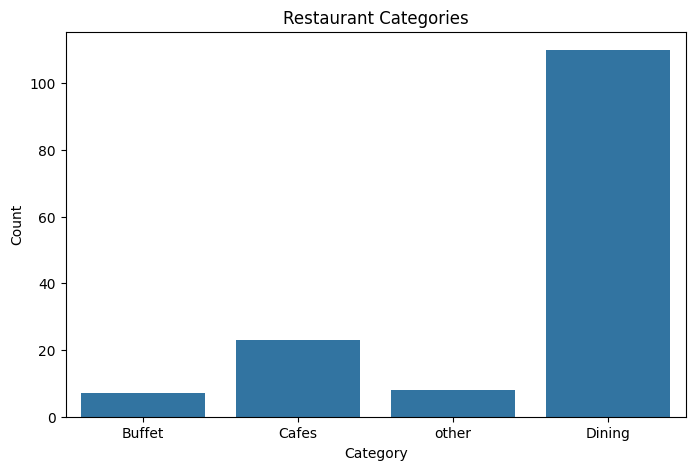

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='listed_in(type)', data=df)

plt.title("Restaurant Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

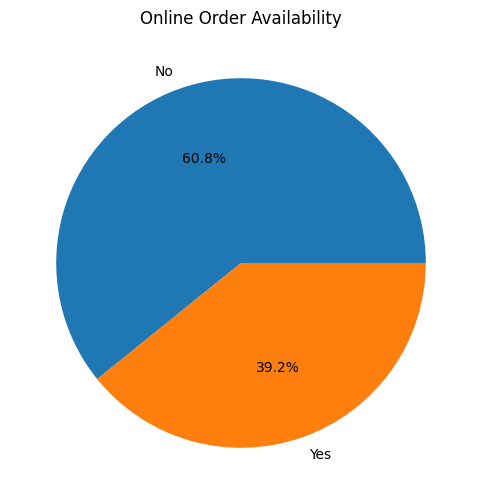

In [ ]:
plt.figure(figsize=(6,6))

df['online_order'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Online Order Availability")

plt.ylabel('')

plt.show()

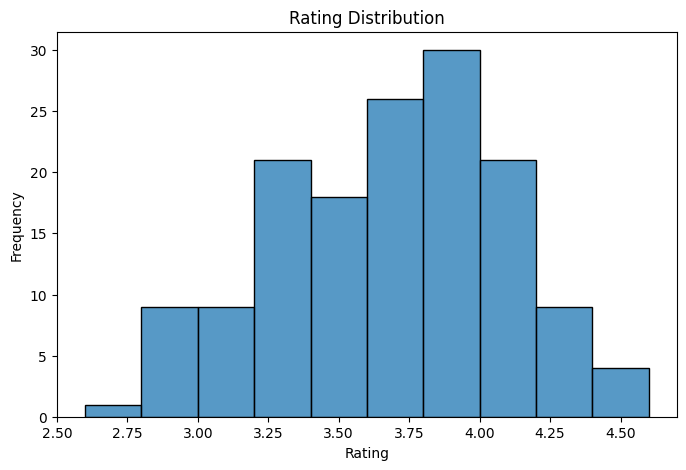

In [ ]:
plt.figure(figsize=(8,5))sns.histplot(df['rate'], bins=10)plt.title("Rating Distribution")plt.xlabel("Rating")plt.ylabel("Frequency")plt.show()

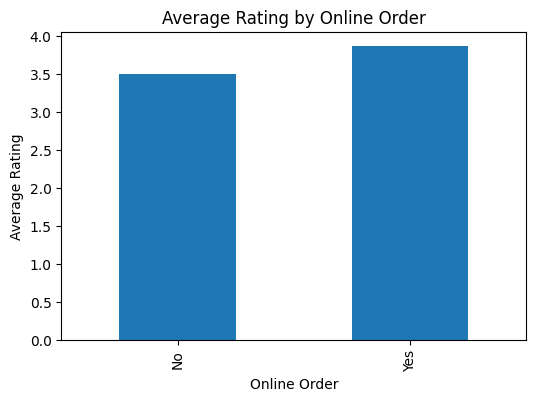

In [ ]:
online_rating = df.groupby('online_order')['rate'].mean()plt.figure(figsize=(6,4))online_rating.plot(kind='bar')plt.title("Average Rating by Online Order")plt.xlabel("Online Order")plt.ylabel("Average Rating")plt.show()

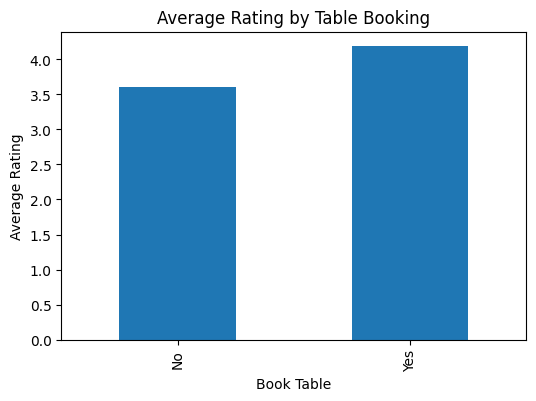

In [ ]:
book_rating = df.groupby('book_table')['rate'].mean()plt.figure(figsize=(6,4))book_rating.plot(kind='bar')plt.title("Average Rating by Table Booking")plt.xlabel("Book Table")plt.ylabel("Average Rating")plt.show()

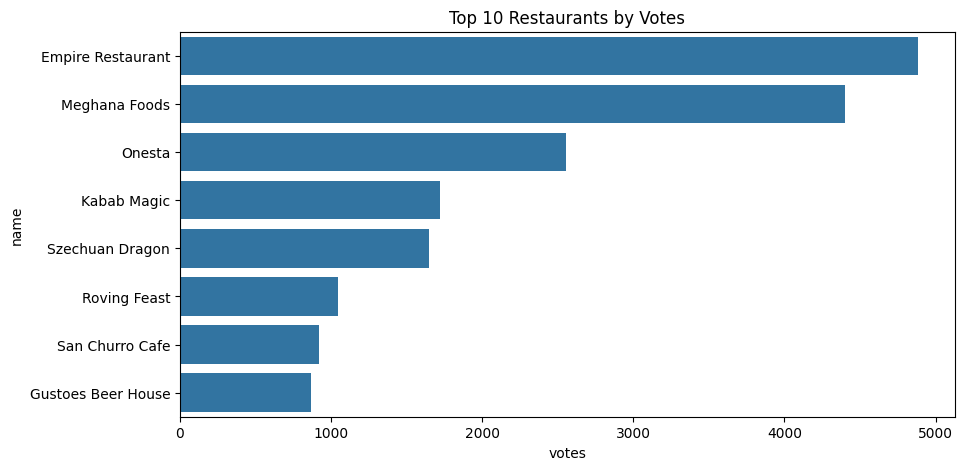

In [ ]:
top_votes = df.sort_values(by='votes',ascending=False).head(10)plt.figure(figsize=(10,5))sns.barplot(x='votes',y='name',data=top_votes)plt.title("Top 10 Restaurants by Votes")plt.show()

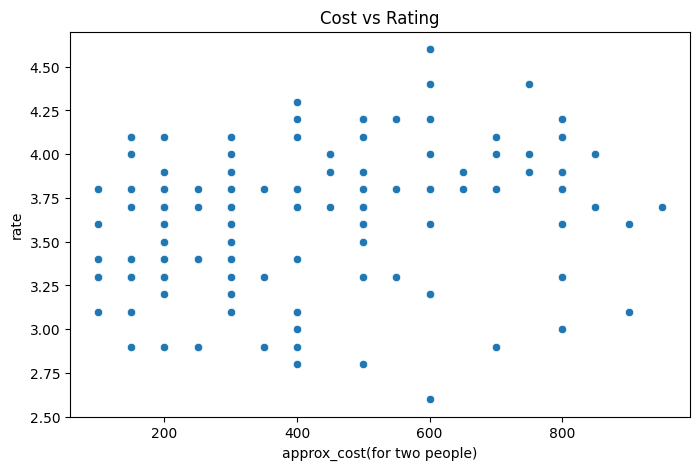

In [ ]:
plt.figure(figsize=(8,5))sns.scatterplot(data=df,x='approx_cost(for two people)',y='rate')plt.title("Cost vs Rating")plt.show()

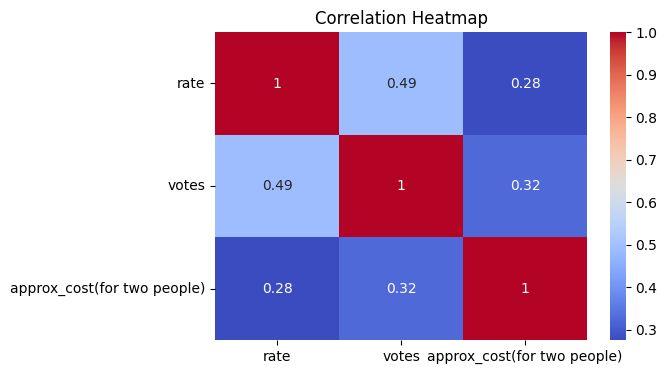

In [ ]:
numeric_df = df.select_dtypes(include=['number'])plt.figure(figsize=(6,4))sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm')plt.title("Correlation Heatmap")plt.show()

In [ ]:
df.describe()

,rate,votes,approx_cost(for two people)
count,148.000000,148.000000,148.000000
mean,3.633108,264.810811,418.243243
std,0.402271,653.676951,223.085098
min,2.600000,0.000000,100.000000
25%,3.300000,6.750000,200.000000
50%,3.700000,43.500000,400.000000
75%,3.900000,221.750000,600.000000
max,4.600000,4884.000000,950.000000


In [ ]:
df.to_csv('cleaned_zomato_dataset.csv', index=False)

print("Dataset saved successfully")

Dataset saved successfully
